In [1]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration, AutoProcessor
from datasets import load_dataset, Audio
from src.ModelWrapper import ModelWrapper
import torch
from pyaml_env import parse_config
from src.utils_contributions import compute_alti
import pandas as pd
import seaborn as sns
#from transformers import pipeline

processor = WhisperProcessor.from_pretrained("openai/whisper-small")
#processor = AutoProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small", attn_implementation="eager")
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
'''
print(model.forward.__annotations__)
print(model.config.output_attentions)
print(model.config.output_hidden_states)
print(model.config.return_dict)
print(config['models'][model.config.model_type])
print(model.config.num_attention_heads)
print(model.config.hidden_size / model.config.num_attention_heads)
print(device)
print(model.model.decoder)
'''     
# outputs = model(output_attentions=True, output_hidden_states=True)
# print(type(outputs))

"\nprint(model.forward.__annotations__)\nprint(model.config.output_attentions)\nprint(model.config.output_hidden_states)\nprint(model.config.return_dict)\nprint(config['models'][model.config.model_type])\nprint(model.config.num_attention_heads)\nprint(model.config.hidden_size / model.config.num_attention_heads)\nprint(device)\nprint(model.model.decoder)\n"

In [2]:
model_wrapped = ModelWrapper(model)

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (f

In [3]:
ds = load_dataset("Isma/librispeech_tiny")
ds = ds["1h"]

In [4]:
def contains_word(example, word):
    return word in example["text"].lower().split()

def transcribe(dataset):
    transcribed_data = []
    generated_ids = []
    decoded_texts = []
    for i, sample in enumerate(dataset):
        audio = sample["audio"]
        inputs = processor(
            audio["array"],
            sampling_rate=audio["sampling_rate"],
            return_tensors="pt",
            return_attention_mask=True
        )
        input_features = inputs.input_features.to(model.device)
        attention_mask = inputs.attention_mask.to(model.device)
        
        generated_ids.append(model.generate(input_features,attention_mask=attention_mask, language="en", task="transcribe", return_token_timestamps=True))
        decoded_texts.append(processor.batch_decode(generated_ids[i]['sequences'], skip_special_tokens=True, decode_with_timestamps=False)[0])
        transcribed_data.append(decoded_texts[i])
    return transcribed_data, generated_ids, decoded_texts

def get_input_features(dataset):
    for i, sample in enumerate(dataset):
       audio = sample["audio"]
       inputs = (processor(
           audio["array"],
           sampling_rate=audio["sampling_rate"],
           return_tensors="pt",
           return_attention_mask=True
        ))
       input_features = inputs.input_features.to(model.device)
       attention_mask = inputs.attention_mask.to(model.device)
       return input_features, attention_mask

def add_forced_ids(gen_ids):
    # get prompt tokens and append to token list
    forced_ids = model.generation_config.forced_decoder_ids
    task_token_id = forced_ids[1][1]
    full_ids = gen_ids['sequences'][0].tolist()
    full_ids.insert(0, task_token_id)
    return torch.tensor(full_ids)

def build_decoder_prefix(decoded_ids_tensor, target_token, skip_special_tokens=True):
    seq = decoded_ids_tensor.tolist()
    assert target_token in seq, "Target token not found in decoded output"
    target_pos = seq.index(target_token)
    
    # decoder prefix
    decoder_input_ids = torch.tensor(
        seq[:target_pos],
        device=model.device
    ).unsqueeze(0)
    return decoder_input_ids

In [5]:
pair_homophones = ds.filter(
    lambda ex: contains_word(ex, "pair") or contains_word(ex, "pear")
)
print(len(pair_homophones))

1


In [6]:
transcriptions, _, _ = transcribe(dataset=pair_homophones)

for i, t in enumerate(transcriptions):
    print(f"Sample {i}: {t}")

Sample 0:  Then he made all his servants go to, his cooks and his gardeners and his barber and Prince Bumpo's tutor, even the queen, who was tired from dancing in a pair of tight shoes.


In [7]:
# define contrastive tokens
target = " pair"
foil = " pear"

# token id extraction
CORRECT_ID = processor.tokenizer(target, add_special_tokens=False).input_ids[0]
FOIL_ID = processor.tokenizer(foil, add_special_tokens=False).input_ids[0]
token = [CORRECT_ID, FOIL_ID]

# get audio features
input_features, attention_mask = get_input_features(pair_homophones)

num_frames = input_features.shape[-1]
print(num_frames)
print(input_features)


# generate transcription
generated_ids = model.generate(input_features, attention_mask=attention_mask, language="en", task="transcribe", return_token_timestamps=True)

full_ids_tensor = add_forced_ids(generated_ids)

decoder_input_ids = build_decoder_prefix(full_ids_tensor, CORRECT_ID, False)

# forward pass with forced decoder prefix
prediction_scores, hidden_states, attentions, encoder_hidden_states, cross_attentions = (
    model_wrapped({
        "input_features": input_features,
        "decoder_input_ids": decoder_input_ids
    })
)

# logit difference at decision point
step_logits = prediction_scores[0, -1]
logit_diff = step_logits[CORRECT_ID] - step_logits[FOIL_ID]
print("logit diff:", logit_diff.item())

logit_trans_vect_dict, logits_modules, layer_alti_data = (
    model_wrapped.get_logit_contributions(
        hidden_states=hidden_states,
        attentions=attentions,
        token=token,
        output_pos=-1,
        encoder_hidden_states=encoder_hidden_states,
        cross_attentions=cross_attentions
    )
)

'''contrastive_contributions = (
    layer_alti_data[CORRECT_ID] - layer_alti_data[FOIL_ID]
)

print(contrastive_contributions)'''

3000
tensor([[[ 0.3031,  0.2751,  0.3278,  ..., -0.6109, -0.6109, -0.6109],
         [ 0.0455,  0.2192,  0.1032,  ..., -0.6109, -0.6109, -0.6109],
         [-0.1529,  0.1662,  0.0982,  ..., -0.6109, -0.6109, -0.6109],
         ...,
         [-0.6109, -0.6109, -0.6109,  ..., -0.6109, -0.6109, -0.6109],
         [-0.6109, -0.6109, -0.6109,  ..., -0.6109, -0.6109, -0.6109],
         [-0.6109, -0.6109, -0.6109,  ..., -0.6109, -0.6109, -0.6109]]])
logit diff: 8.311716079711914
model.decoder.layers
model.decoder.layers
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 38, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 38, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 38, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 38, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 38, 768])
unembed:  torch.S

'contrastive_contributions = (\n    layer_alti_data[CORRECT_ID] - layer_alti_data[FOIL_ID]\n)\n\nprint(contrastive_contributions)'

How much did encoder cross-attention contribute to the logit difference between two tokens, aggregated over encoder positions

<Axes: >

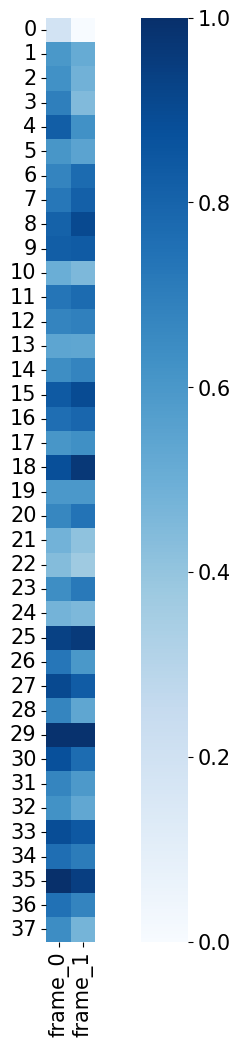

In [8]:
layer_idx = -1
# sum over heads and vocab dimension to get frame-level contribution
frame_contributions = logit_trans_vect_dict['lin_x_j_h'].sum(axis=1).sum(axis=-1)  # [layers, tgt_len, src_len]
fc = frame_contributions[layer_idx]
fc = (fc - fc.min()) / (fc.max() - fc.min() + 1e-8)

layer_idx = -1
df = pd.DataFrame(fc.cpu().numpy(), columns=[f"frame_{i}" for i in range(fc.shape[-1])])
sns.heatmap(df, cmap="Blues", square=True)


## alti input attributions to model outputs

['<|transcribe|>', 'ĠThen', 'Ġhe', 'Ġmade', 'Ġall', 'Ġhis', 'Ġservants', 'Ġgo', 'Ġto', ',', 'Ġhis', 'Ġcooks', 'Ġand', 'Ġhis', 'Ġgarden', 'ers', 'Ġand', 'Ġhis', 'Ġbarber', 'Ġand', 'ĠPrince', 'ĠB', 'um', 'po', "'s", 'Ġtutor', ',', 'Ġeven', 'Ġthe', 'Ġqueen', ',', 'Ġwho', 'Ġwas', 'Ġtired', 'Ġfrom', 'Ġdancing', 'Ġin', 'Ġa']


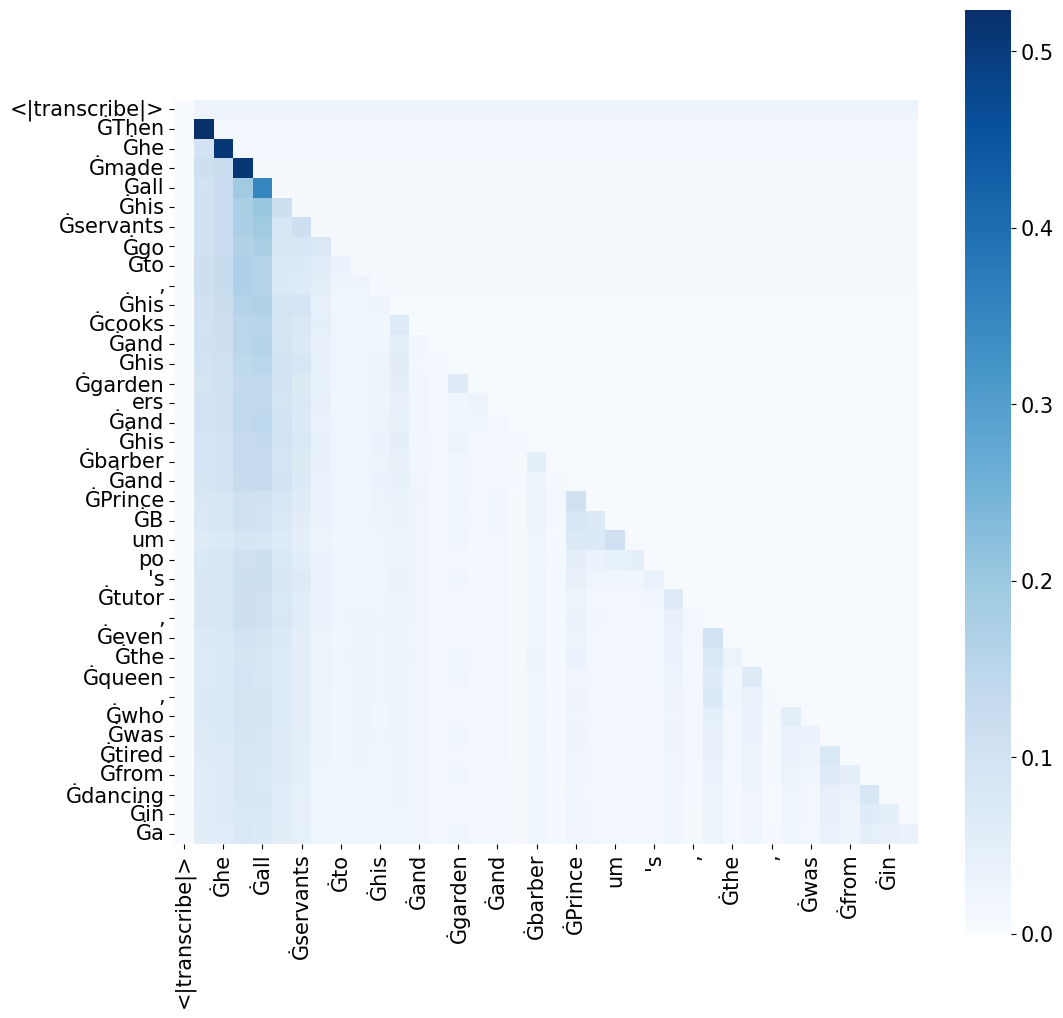

In [9]:
import numpy as np

contributions_mix_alti = compute_alti(layer_alti_data)

tokenized_text = processor.tokenizer.convert_ids_to_tokens( 
    decoder_input_ids[0].tolist()[:CORRECT_ID]
) 
print(tokenized_text)

df = pd.DataFrame(np.array(contributions_mix_alti[-1]),columns=tokenized_text,index=tokenized_text)
sns.heatmap(df,cmap="Blues",square=True);

## per layer heatmap

<Axes: >

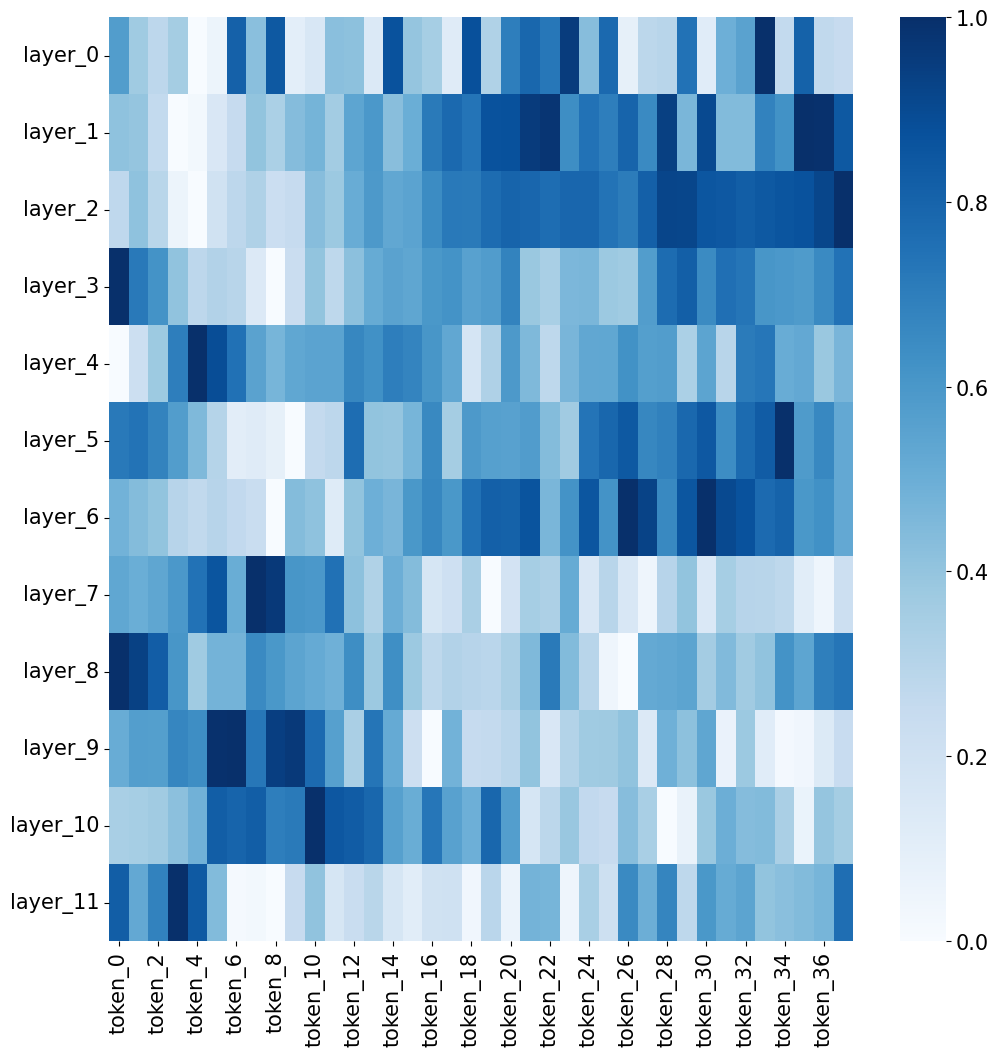

In [10]:
fc_all = frame_contributions.cpu().numpy()
fc_all = fc_all[..., 0] - fc_all[..., 1]
# optional normalization per layer
fc_all = (fc_all - fc_all.min(axis=1, keepdims=True)) / (
    fc_all.max(axis=1, keepdims=True) - fc_all.min(axis=1, keepdims=True) + 1e-8
)

df = pd.DataFrame(
    fc_all,
    columns=[f"token_{i}" for i in range(fc_all.shape[1])],
    index=[f"layer_{i}" for i in range(fc_all.shape[0])]
)

sns.heatmap(df, cmap="Blues", cbar=True)


Text(0.5, 1.0, 'Cross-attention frame contribution (layer -1)')

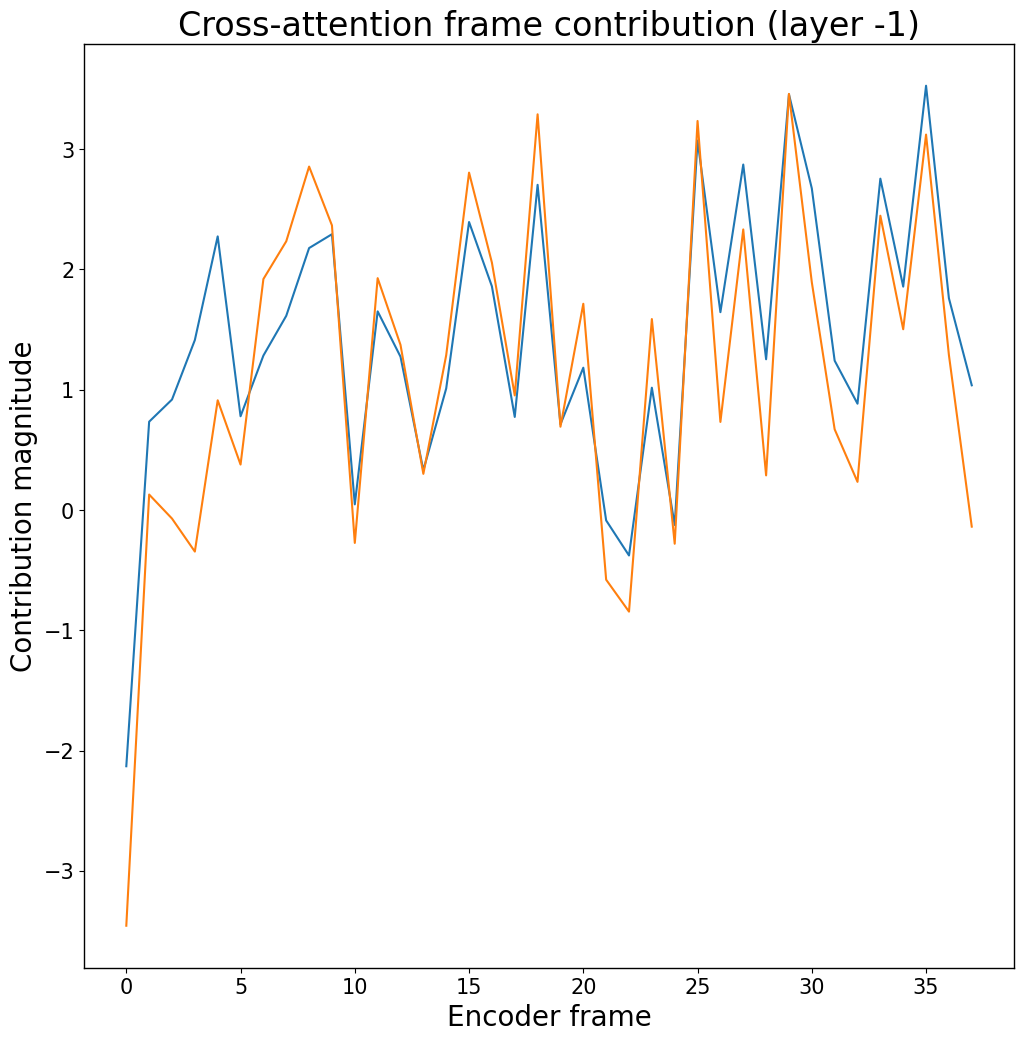

In [11]:
import matplotlib.pyplot as plt
fc = frame_contributions[layer_idx]
#fc = (fc - fc.min()) / (fc.max() - fc.min() + 1e-8)

x = fc.cpu().numpy()
plt.plot(x)
plt.xlabel("Encoder frame")
plt.ylabel("Contribution magnitude")
plt.title(f"Cross-attention frame contribution (layer {layer_idx})")

In [12]:
from extract_explanations import track2input_tokens

methods_decomp = ["aff_x_j"]
alti_lg_dict = track2input_tokens(logit_trans_vect_dict, methods_decomp, contributions_mix_alti, token)
alti_lg_dict.keys()

dict_keys(['logit_aff_x_j', 'logit_aff_x_j_alti'])

tensor(2.7937)


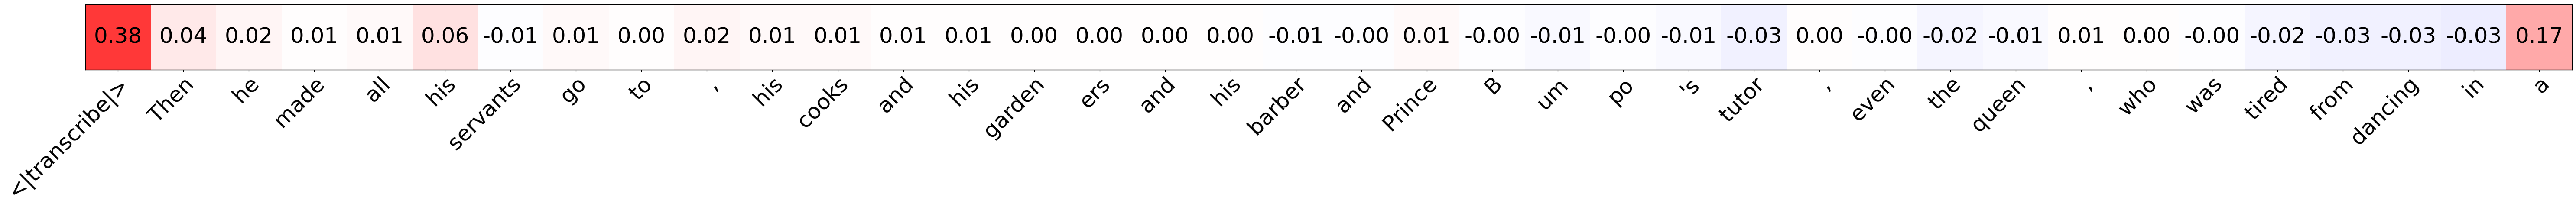

In [13]:
# 'logit_aff_x_j_alti' ALTI-Logit explanation
# 'logit_aff_x_j' Logit explanation
method = 'logit_aff_x_j'

# Contrastive explanation
contrastive_contributions = (alti_lg_dict[method][0] - alti_lg_dict[method][1]).sum(0)

# Add inital logit update by last postion intial embedding (see Eq. 7 paper)
init_logits_diff = (logits_modules['init_logit'][0] - logits_modules['init_logit'][1]).to('cpu')
contrastive_contributions[-1] += init_logits_diff
print(contrastive_contributions.sum())

from lm_saliency import *
# Normalization done in Kayo's work
# Divides by the sum of the absolute values (l1) of the explanations vector
norm = np.linalg.norm(contrastive_contributions, ord=1)
contrastive_contributions /= norm
explanations_list = []
explanations_list.append(contrastive_contributions)
# Yin and Neubig visualization (https://github.com/kayoyin/interpret-lm)
visualize(np.array(contrastive_contributions), processor.tokenizer, decoder_input_ids, print_text=True, normalize=False)
# Barplot visualization
#utils_contributions.plot_histogram(contrastive_contributions,tokenized_text)

In [15]:
input_tokens = input_features
attention_ids = attention_mask

explanations = ["erasure", "gradient norm", "input x gradient"]

for explanation in explanations:
  if explanation == "erasure":
    base_explanation = erasure_scores(model, input_tokens, attention_ids, normalize=True)
    contra_explanation = erasure_scores(model, input_tokens, attention_ids, correct=CORRECT_ID, foil=FOIL_ID, normalize=True)
  else:
    #base_saliency_matrix, base_embd_matrix = saliency(model, input_tokens, attention_ids, correct=CORRECT_ID)
    saliency_matrix, embd_matrix = saliency(model, input_tokens, attention_ids, correct=CORRECT_ID, foil=FOIL_ID)
    if explanation == "input x gradient":
      #base_explanation = input_x_gradient(base_saliency_matrix, base_embd_matrix, normalize=True)
      contra_explanation = input_x_gradient(saliency_matrix, embd_matrix, normalize=True)
    elif explanation == "gradient norm":
      #base_explanation = l1_grad_norm(base_saliency_matrix, normalize=True)
      contra_explanation = l1_grad_norm(saliency_matrix, normalize=True)

  explanations_list.append(contra_explanation)
  #visualize(np.array(base_explanation), tokenizer, [input_tokens], print_text=True, title=f"Why did the model predict {target}? ({explanation})")
  visualize(np.array(contra_explanation), tokenizer, [input_tokens], print_text=True, title=f"Why did the model predict {target} instead of {foil}? ({explanation})")


RuntimeError: Input type (long int) and bias type (float) should be the same